<a href="https://colab.research.google.com/github/Asif1900/Programming-for-Data-Analysis-Project/blob/main/Programming_for_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [8]:
df = pd.read_csv("all_cities_combined.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [9]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 140256
Number of columns: 18


In [10]:
df.columns.tolist()

['No',
 'year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'station']

In [11]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
No,140256.0,17532.500000,10122.141000,1.0000,8766.75,17532.5,26298.250,35064.0
year,140256.0,2014.662560,1.177201,2013.0000,2014.00,2015.0,2016.000,2017.0
month,140256.0,6.522930,3.448715,1.0000,4.00,7.0,10.000,12.0
day,140256.0,15.729637,8.800123,1.0000,8.00,16.0,23.000,31.0
hour,140256.0,11.500000,6.922211,0.0000,5.75,11.5,17.250,23.0
PM2.5,137163.0,77.481501,78.366874,2.0000,20.00,53.0,108.000,882.0
PM10,137915.0,101.399508,89.753213,2.0000,35.00,79.0,141.000,999.0
SO2,137511.0,15.811354,21.822958,0.2856,2.00,7.0,20.000,315.0
NO2,135690.0,47.129503,32.961087,1.0265,22.00,39.0,65.696,270.0
CO,132363.0,1192.068962,1100.290695,100.0000,500.00,900.0,1500.000,10000.0


In [13]:
df.describe(include='object')

,wd,station
count,139655,140256
unique,16,4
top,NW,Guanyuan
freq,13107,35064


In [14]:
df['station'].value_counts()

,count
station,
Guanyuan,35064
Huairou,35064
Changping,35064
Dongsi,35064


In [15]:
selected_stations = ['Dongsi', 'Guanyuan', 'Changping', 'Huairou']
df = df[df['station'].isin(selected_stations)].copy()

print(df['station'].value_counts())
print(df.shape)

station
Guanyuan     35064
Huairou      35064
Changping    35064
Dongsi       35064
Name: count, dtype: int64
(140256, 18)


In [16]:
df.to_csv("selected_stations_combined.csv", index=False)
print("Filtered dataset saved as selected_stations_combined.csv")

Filtered dataset saved as selected_stations_combined.csv


In [17]:
def missing_values_table(dataframe):
    missing_count = dataframe.isnull().sum()
    missing_percent = (missing_count / len(dataframe)) * 100

    table = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent
    })

    table = table.sort_values(by='Percentage (%)', ascending=False)
    return table

In [18]:
missing_table = missing_values_table(df)
missing_table

,Missing Values,Percentage (%)
CO,7893,5.627567
NO2,4566,3.255476
O3,3592,2.561031
PM2.5,3093,2.205253
SO2,2745,1.957136
PM10,2341,1.669091
wd,601,0.428502
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


In [19]:
missing_table.style.background_gradient(cmap='Blues')

,Missing Values,Percentage (%)
CO,7893,5.627567
NO2,4566,3.255476
O3,3592,2.561031
PM2.5,3093,2.205253
SO2,2745,1.957136
PM10,2341,1.669091
wd,601,0.428502
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [21]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (140256, 18)


In [22]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df[['year', 'month', 'day', 'hour', 'datetime']].head()

,year,month,day,hour,datetime
0,2013,3,1,0,2013-03-01 00:00:00
1,2013,3,1,1,2013-03-01 01:00:00
2,2013,3,1,2,2013-03-01 02:00:00
3,2013,3,1,3,2013-03-01 03:00:00
4,2013,3,1,4,2013-03-01 04:00:00


In [23]:
df = df.sort_values(by=['station', 'datetime']).reset_index(drop=True)

In [24]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df.groupby('station')[col].transform(lambda x: x.fillna(x.median()))

In [25]:
if 'wd' in df.columns:
    df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

In [26]:
missing_values_table(df)

,Missing Values,Percentage (%)
No,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0
hour,0,0.0
PM2.5,0,0.0
PM10,0,0.0
SO2,0,0.0
NO2,0,0.0
CO,0,0.0


In [27]:
df['day_of_week'] = df['datetime'].dt.day_name()
df['month_name'] = df['datetime'].dt.month_name()
df['weekend'] = df['datetime'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

In [28]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)

In [29]:
df['area_type'] = df['station'].map({
    'Dongsi': 'Urban',
    'Guanyuan': 'Urban',
    'Changping': 'Suburban',
    'Huairou': 'Suburban'
})

In [30]:
def pm25_category(value):
    if pd.isna(value):
        return np.nan
    elif value <= 35:
        return 'Good'
    elif value <= 75:
        return 'Moderate'
    elif value <= 115:
        return 'Unhealthy for Sensitive'
    elif value <= 150:
        return 'Unhealthy'
    elif value <= 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['PM2.5_Level'] = df['PM2.5'].apply(pm25_category)

In [31]:
df.to_csv("cleaned_selected_air_quality.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 25 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   No           140256 non-null  int64         
 1   year         140256 non-null  int64         
 2   month        140256 non-null  int64         
 3   day          140256 non-null  int64         
 4   hour         140256 non-null  int64         
 5   PM2.5        140256 non-null  float64       
 6   PM10         140256 non-null  float64       
 7   SO2          140256 non-null  float64       
 8   NO2          140256 non-null  float64       
 9   CO           140256 non-null  float64       
 10  O3           140256 non-null  float64       
 11  TEMP         140256 non-null  float64       
 12  PRES         140256 non-null  float64       
 13  DEWP         140256 non-null  float64       
 14  RAIN         140256 non-null  float64       
 15  wd           140256 non-null  obje

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Make sure datetime exists
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")

# Keep only selected stations if needed
selected_stations = ["Dongsi", "Guanyuan", "Changping", "Huairou"]
df = df[df["station"].isin(selected_stations)].copy()

# Area type
df["area_type"] = df["station"].map({
    "Dongsi": "Urban",
    "Guanyuan": "Urban",
    "Changping": "Suburban",
    "Huairou": "Suburban"
})

# Season
def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    return "Winter"

df["season"] = df["month"].apply(get_season)
df["day_of_week"] = df["datetime"].dt.day_name()
df["weekend"] = df["datetime"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 5 else "Weekday")

/tmp/ipykernel_16493/2676277849.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


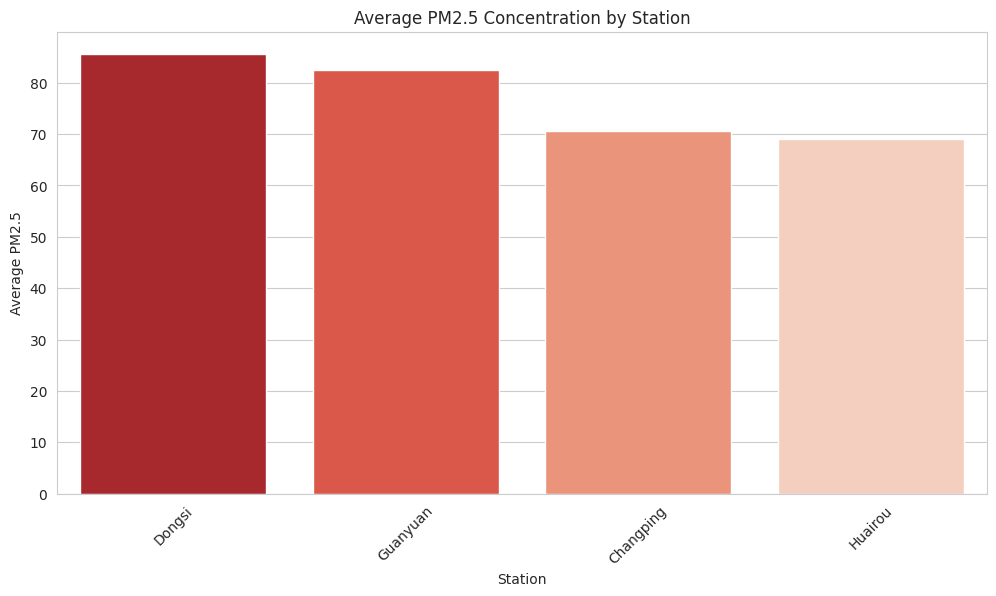

In [34]:
station_pollution = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=station_pollution.index,
    y=station_pollution.values,
    palette='Reds_r'
)

plt.title('Average PM2.5 Concentration by Station')
plt.xlabel('Station')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)
plt.show()

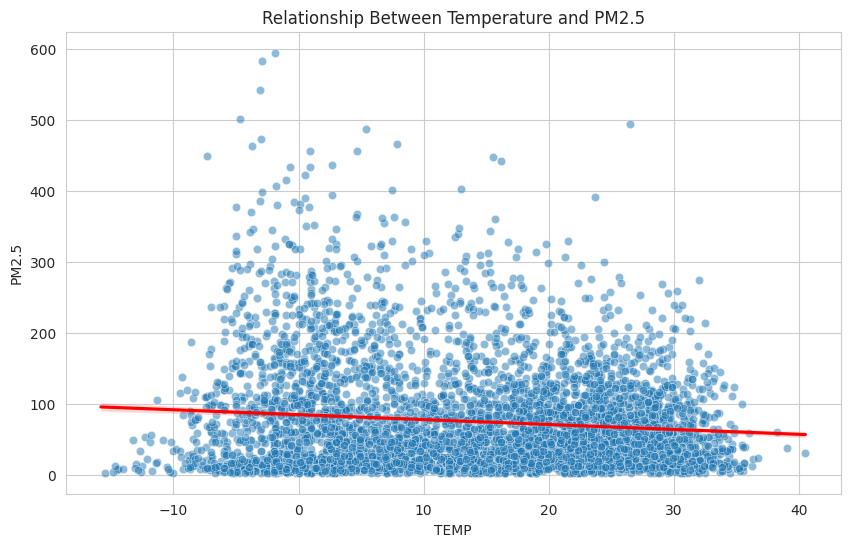

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x='TEMP',
    y='PM2.5',
    alpha=0.5
)

sns.regplot(
    data=df.sample(5000),
    x='TEMP',
    y='PM2.5',
    scatter=False,
    color='red'
)

plt.title('Relationship Between Temperature and PM2.5')
plt.show()

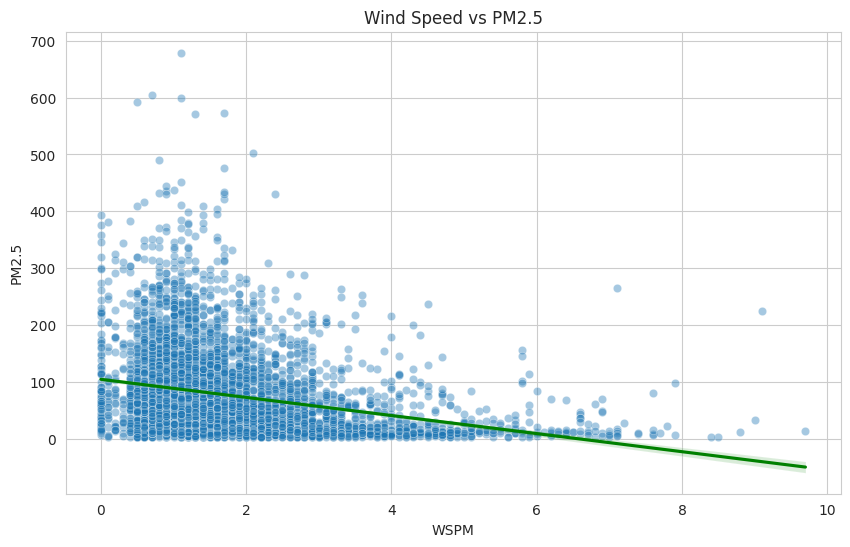

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x='WSPM',
    y='PM2.5',
    alpha=0.4
)

sns.regplot(
    data=df.sample(5000),
    x='WSPM',
    y='PM2.5',
    scatter=False,
    color='green'
)

plt.title('Wind Speed vs PM2.5')
plt.show()

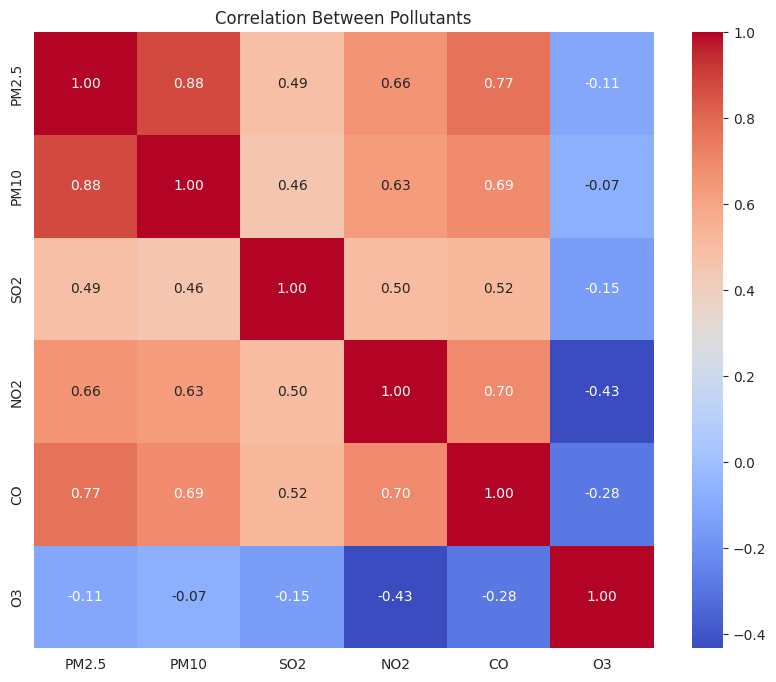

In [37]:
pollutants = ['PM2.5','PM10','SO2','NO2','CO','O3']

corr = df[pollutants].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Pollutants')
plt.show()

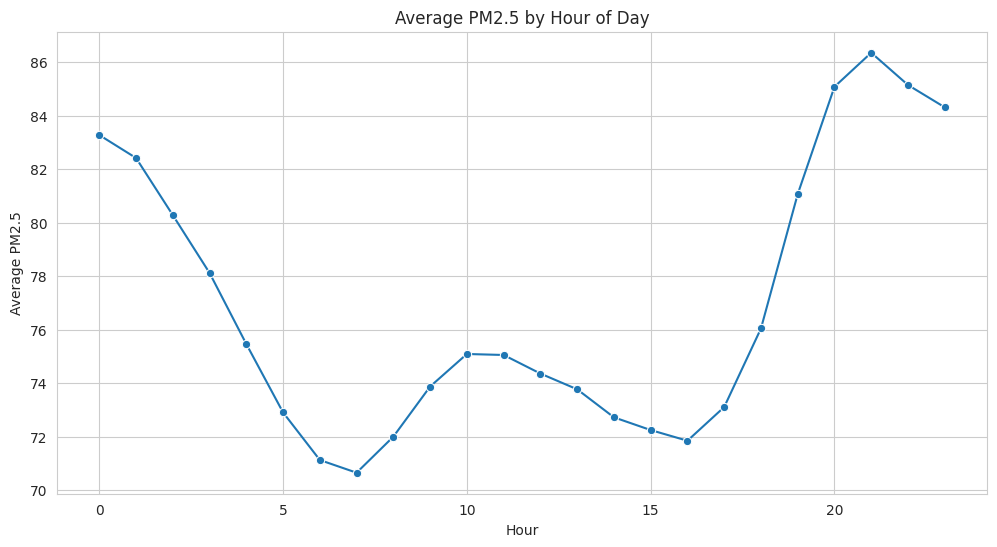

In [38]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_pm25.index,
    y=hourly_pm25.values,
    marker='o'
)

plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average PM2.5')
plt.show()

/tmp/ipykernel_16493/20092270.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


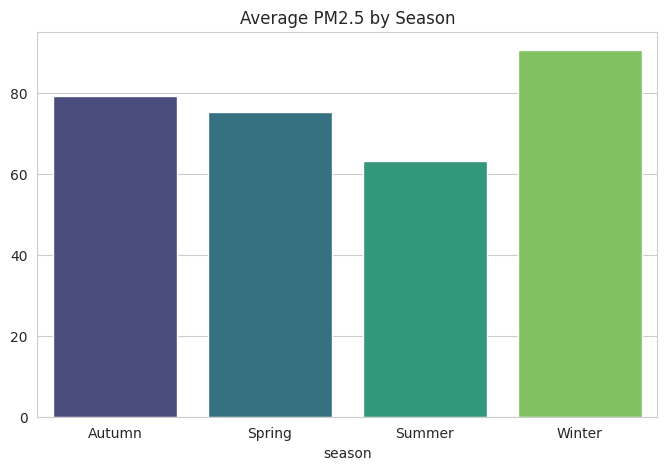

In [39]:
season_pm25 = df.groupby('season')['PM2.5'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_pm25.index,
    y=season_pm25.values,
    palette='viridis'
)

plt.title('Average PM2.5 by Season')
plt.show()

In [ ]:
! git config --global user.name "Asif1900" # replace with your username that you used to create the Github account
! git config --global user.email "asifabdullah1900@gmail.com" # and the email id which you have used to create account

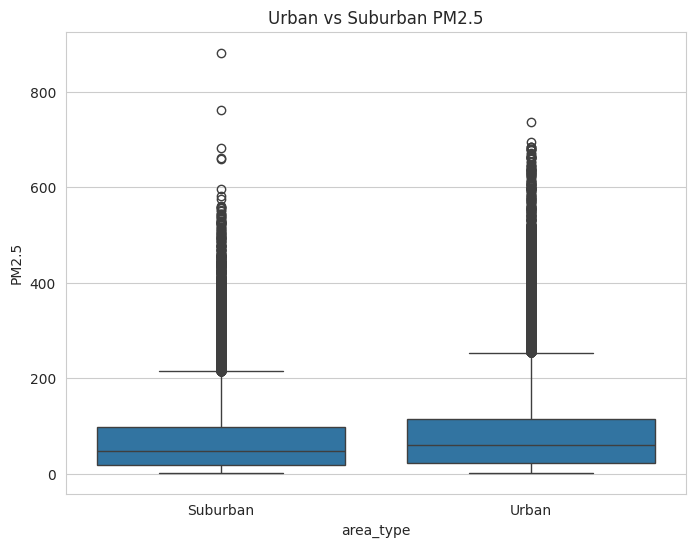

In [40]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='area_type',
    y='PM2.5'
)

plt.title('Urban vs Suburban PM2.5')
plt.show()

/tmp/ipykernel_16493/1643248829.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df.groupby(pd.Grouper(key='datetime', freq='M'))['PM2.5'].mean()


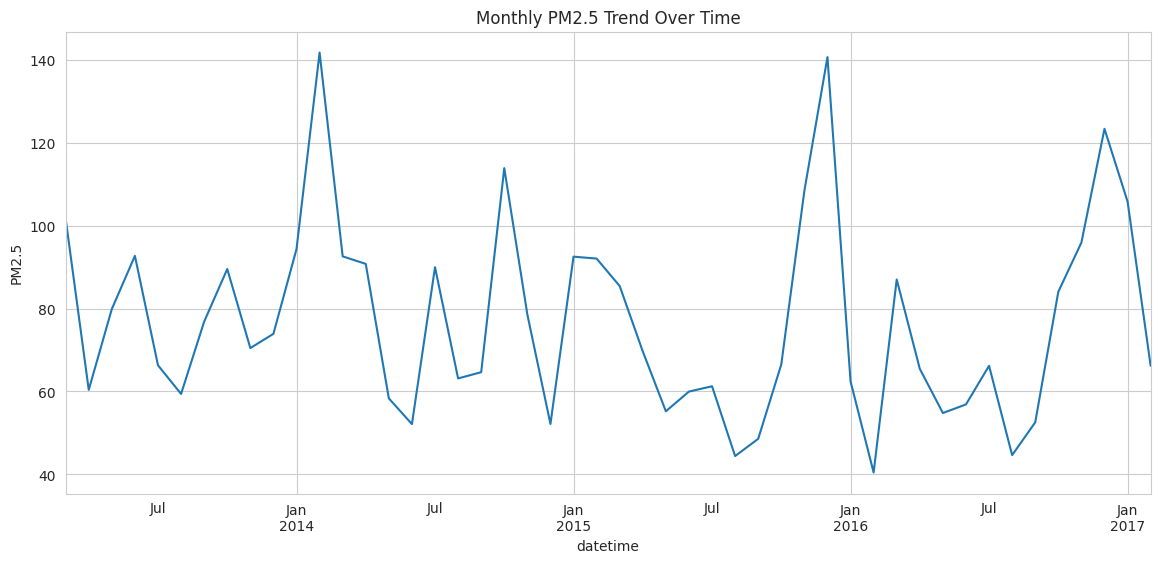

In [41]:
monthly_trend = df.groupby(pd.Grouper(key='datetime', freq='M'))['PM2.5'].mean()

plt.figure(figsize=(14,6))

monthly_trend.plot()

plt.title('Monthly PM2.5 Trend Over Time')
plt.ylabel('PM2.5')
plt.show()

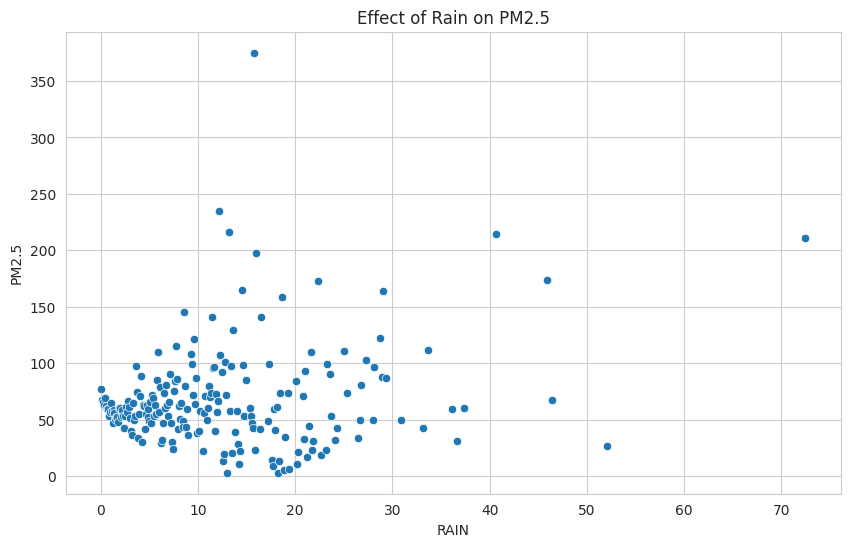

In [42]:
rain_effect = df.groupby('RAIN')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rain_effect,
    x='RAIN',
    y='PM2.5'
)

plt.title('Effect of Rain on PM2.5')
plt.show()

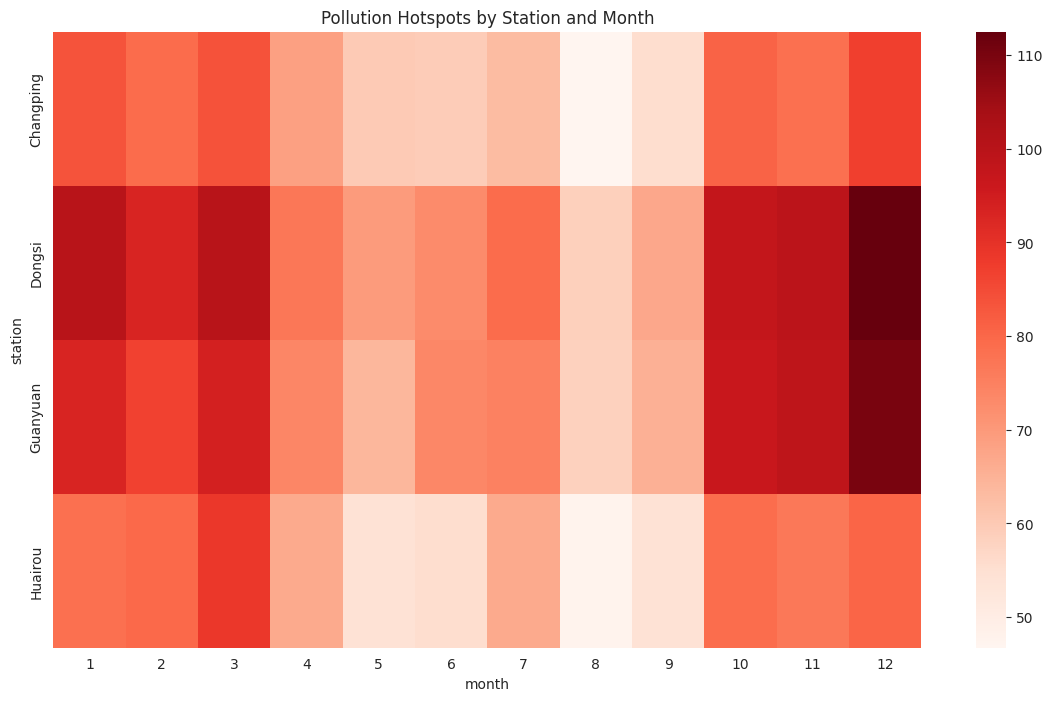

In [43]:
pivot_table = df.pivot_table(
    values='PM2.5',
    index='station',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    cmap='Reds'
)

plt.title('Pollution Hotspots by Station and Month')
plt.show()

In [44]:
df["date"] = df["datetime"].dt.date
df["high_pollution"] = df["PM2.5"] > 150

daily_episode = df.groupby("date").agg(
    avg_pm25=("PM2.5", "mean"),
    high_events=("high_pollution", "sum")
).reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_episode["date"],
    y=daily_episode["avg_pm25"],
    mode="lines",
    name="Daily Average PM2.5",
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=daily_episode[daily_episode["avg_pm25"] > 150]["date"],
    y=daily_episode[daily_episode["avg_pm25"] > 150]["avg_pm25"],
    mode="markers",
    name="Extreme Pollution Days",
    marker=dict(size=8, color="red")
))

fig.add_hline(
    y=150,
    line_dash="dash",
    line_color="red",
    annotation_text="Unhealthy Threshold"
)

fig.update_layout(
    title="Extreme Pollution Episodes Over Time",
    xaxis_title="Date",
    yaxis_title="PM2.5",
    template="plotly_white",
    height=500
)

fig.show()

In [45]:
df["wind_condition"] = np.where(df["WSPM"] < 2, "Low Wind", "Higher Wind")

wind_station = df.groupby(["station", "wind_condition"])["PM2.5"].mean().reset_index()

fig = px.bar(
    wind_station,
    x="station",
    y="PM2.5",
    color="wind_condition",
    barmode="group",
    title="Impact of Wind Conditions on PM2.5 by Station",
    labels={"PM2.5": "Average PM2.5", "station": "Station", "wind_condition": "Wind Condition"}
)

fig.update_layout(
    template="plotly_white",
    height=500,
    legend_title="Wind Condition"
)

fig.show()

In [46]:
df["rush_period"] = df["hour"].apply(
    lambda x: "Morning Rush" if x in [7, 8, 9]
    else "Evening Rush" if x in [17, 18, 19]
    else "Other Hours"
)

rush_summary = df.groupby(["hour", "station"])["NO2"].mean().reset_index()

fig = px.line(
    rush_summary,
    x="hour",
    y="NO2",
    color="station",
    markers=True,
    title="NO2 Traffic Pollution Signature Across the Day",
    labels={"NO2": "Average NO2", "hour": "Hour of Day"}
)

fig.add_vrect(x0=7, x1=9, fillcolor="orange", opacity=0.18, line_width=0)
fig.add_vrect(x0=17, x1=19, fillcolor="red", opacity=0.15, line_width=0)

fig.add_annotation(x=8, y=rush_summary["NO2"].max(), text="Morning Rush", showarrow=False)
fig.add_annotation(x=18, y=rush_summary["NO2"].max(), text="Evening Rush", showarrow=False)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

In [47]:
station_monthly = df.pivot_table(
    values="PM2.5",
    index=df["datetime"].dt.to_period("M").astype(str),
    columns="station",
    aggfunc="mean"
)

station_corr = station_monthly.corr()

fig = go.Figure(data=go.Heatmap(
    z=station_corr.values,
    x=station_corr.columns,
    y=station_corr.index,
    colorscale="Blues",
    text=np.round(station_corr.values, 2),
    texttemplate="%{text}",
    zmin=0,
    zmax=1
))

fig.update_layout(
    title="Station Similarity Based on Monthly PM2.5 Behaviour",
    xaxis_title="Station",
    yaxis_title="Station",
    template="plotly_white",
    height=550
)

fig.show()

In [48]:
df["condition_type"] = np.select(
    [
        (df["TEMP"] < 0) & (df["WSPM"] < 2),
        (df["TEMP"] < 0) & (df["WSPM"] >= 2),
        (df["TEMP"] >= 0) & (df["WSPM"] < 2),
        (df["TEMP"] >= 0) & (df["WSPM"] >= 2)
    ],
    [
        "Cold + Low Wind",
        "Cold + Higher Wind",
        "Warm + Low Wind",
        "Warm + Higher Wind"
    ],
    default="Other"
)

condition_station = df.groupby(["condition_type", "station"])["PM2.5"].mean().reset_index()

order = [
    "Cold + Low Wind",
    "Cold + Higher Wind",
    "Warm + Low Wind",
    "Warm + Higher Wind"
]

fig = px.bar(
    condition_station,
    x="condition_type",
    y="PM2.5",
    color="station",
    barmode="group",
    category_orders={"condition_type": order},
    title="PM2.5 Risk Under Combined Temperature and Wind Conditions",
    labels={"condition_type": "Environmental Condition", "PM2.5": "Average PM2.5"}
)

fig.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-20
)

fig.show()

In [ ]:
sample_df = df[["TEMP", "WSPM", "PM2.5", "station"]].dropna().sample(min(5000, df[["TEMP", "WSPM", "PM2.5", "station"]].dropna().shape[0]), random_state=42)

fig = px.scatter_3d(
    sample_df,
    x="TEMP",
    y="WSPM",
    z="PM2.5",
    color="station",
    title="3D Relationship Between Temperature, Wind Speed, and PM2.5"
)
fig.show()

In [ ]:
sample_df = df[["TEMP", "PM2.5", "CO", "station"]].dropna().sample(min(5000, df[["TEMP", "PM2.5", "CO", "station"]].dropna().shape[0]), random_state=42)

fig = px.scatter(
    sample_df,
    x="TEMP",
    y="PM2.5",
    size="CO",
    color="station",
    title="PM2.5 vs Temperature (Bubble Size = CO)"
)
fig.show()

In [ ]:
model_df = df.copy()

# Add lag feature (VERY POWERFUL)
model_df['PM2.5_lag1'] = model_df.groupby('station')['PM2.5'].shift(1)

# Drop missing
model_df = model_df.dropna()

In [ ]:
features = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'PM2.5_lag1'
]

target = 'PM2.5'

X = model_df[features]
y = model_df[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 150}


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV Scores: [0.94645128 0.96039544 0.96929848 0.964115   0.96248547]
Mean CV R2: 0.9605491358079357


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Model Performance:")
print("RMSE:", rmse)
print("R2:", r2)

Final Model Performance:
RMSE: 14.79650062722952
R2: 0.9628980079957903


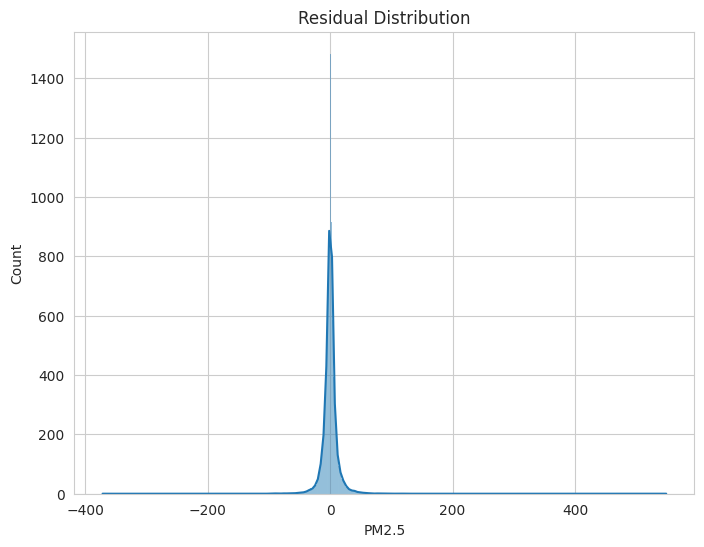

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

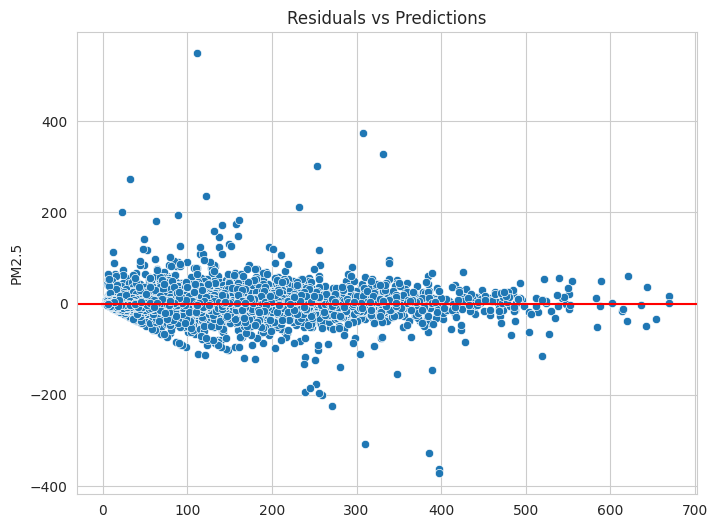

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")
plt.show()

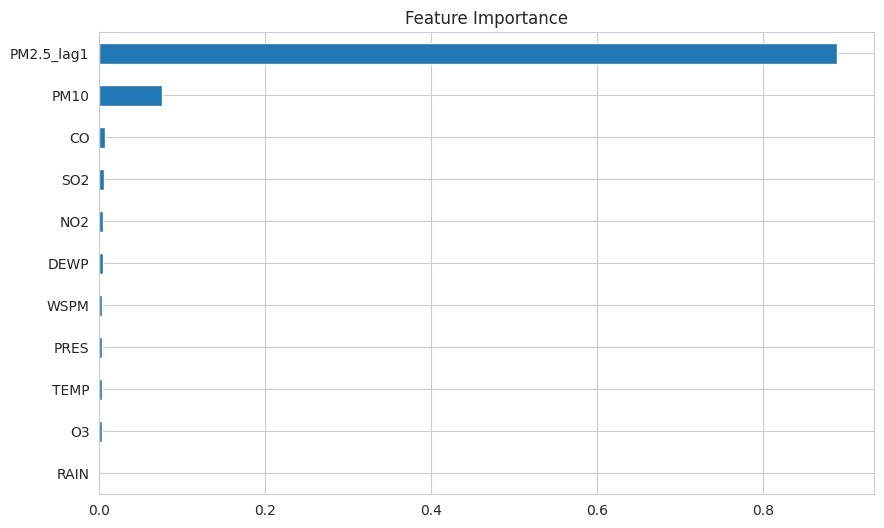

In [ ]:
model = best_model.named_steps['model']

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

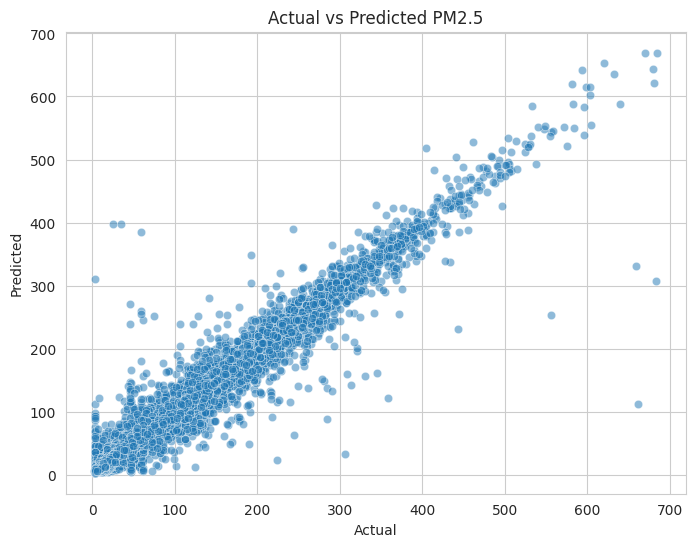

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted PM2.5")
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "best_pm25_model.pkl")

['best_pm25_model.pkl']

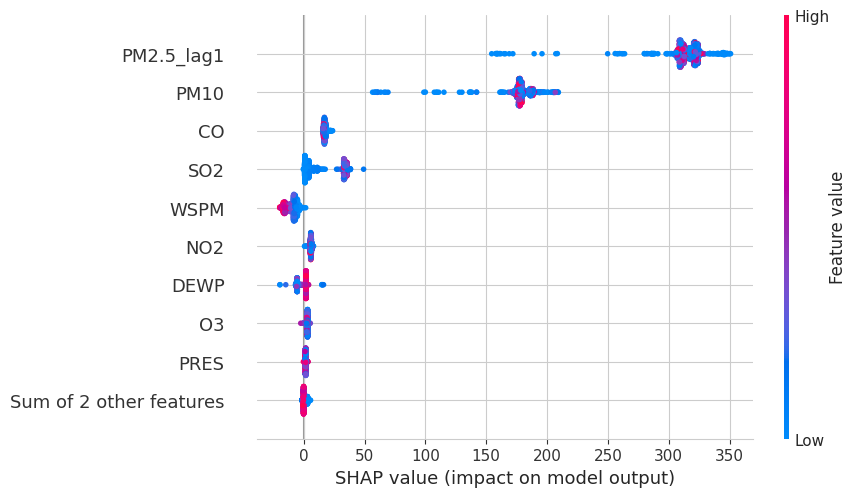

In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test[:1000])

shap.plots.beeswarm(shap_values)

In [ ]:
df.to_csv("cleaned_selected_air_quality.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


In [ ]:
import joblib

joblib.dump(best_model, "best_pm25_model.pkl")
print("Model saved.")

Model saved.


In [ ]:
import os

print(os.path.exists("cleaned_selected_air_quality.csv"))
print(os.path.exists("best_pm25_model.pkl"))

True
True


In [ ]:
!pip install streamlit pyngrok joblib plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 38.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

Writing app.py


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

# -------------------------------------------------
# Page config
# -------------------------------------------------
st.set_page_config(
    page_title="Beijing Air Pollution Dashboard",
    page_icon="🌍",
    layout="wide",
    initial_sidebar_state="expanded"
)

# -------------------------------------------------
# Custom CSS
# -------------------------------------------------
st.markdown("""
<style>
    .main {
        background: linear-gradient(to bottom, #f8fafc, #eef2f7);
    }

    .block-container {
        padding-top: 1.5rem;
        padding-bottom: 2rem;
        padding-left: 2rem;
        padding-right: 2rem;
    }

    section[data-testid="stSidebar"] {
        background: linear-gradient(180deg, #0f172a 0%, #1e293b 100%);
    }

    section[data-testid="stSidebar"] * {
        color: white !important;
    }

    .hero-title {
        font-size: 2.7rem;
        font-weight: 800;
        color: #0f172a;
        margin-bottom: 0.3rem;
    }

    .hero-subtitle {
        font-size: 1.1rem;
        color: #475569;
        margin-bottom: 1rem;
    }

    .glass-card {
        background: rgba(255,255,255,0.88);
        border-radius: 18px;
        padding: 18px 20px;
        box-shadow: 0 6px 22px rgba(15, 23, 42, 0.08);
        border: 1px solid rgba(226, 232, 240, 0.8);
    }

    .metric-label {
        font-size: 0.95rem;
        color: #64748b;
        font-weight: 600;
    }

    .metric-value {
        font-size: 1.8rem;
        font-weight: 800;
        color: #0f172a;
    }

    .section-title {
        font-size: 1.4rem;
        font-weight: 700;
        color: #0f172a;
        margin-top: 0.5rem;
        margin-bottom: 0.8rem;
    }

    .prediction-good {
        background: linear-gradient(90deg, #dcfce7, #bbf7d0);
        color: #166534;
        padding: 18px;
        border-radius: 16px;
        font-weight: 700;
        border: 1px solid #86efac;
    }

    .prediction-moderate {
        background: linear-gradient(90deg, #fef9c3, #fde68a);
        color: #854d0e;
        padding: 18px;
        border-radius: 16px;
        font-weight: 700;
        border: 1px solid #facc15;
    }

    .prediction-unhealthy {
        background: linear-gradient(90deg, #fee2e2, #fecaca);
        color: #991b1b;
        padding: 18px;
        border-radius: 16px;
        font-weight: 700;
        border: 1px solid #f87171;
    }

    .small-note {
        color: #64748b;
        font-size: 0.95rem;
    }

    .footer-text {
        text-align: center;
        color: #64748b;
        font-size: 0.9rem;
        margin-top: 1rem;
    }
</style>
""", unsafe_allow_html=True)

# -------------------------------------------------
# Load data and model
# -------------------------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("cleaned_selected_air_quality.csv")
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    return df

@st.cache_resource
def load_model():
    return joblib.load("best_pm25_model.pkl")

df = load_data()
model = load_model()

# -------------------------------------------------
# Sidebar
# -------------------------------------------------
st.sidebar.markdown("## 🌫️ Air Quality Dashboard")
st.sidebar.markdown("Explore, compare, and predict Beijing air pollution patterns.")

page = st.sidebar.radio(
    "Navigation",
    ["Home", "Dataset Overview", "Visual Analytics", "Station Comparison", "Prediction Lab"]
)

st.sidebar.markdown("---")

stations_available = sorted(df["station"].dropna().unique().tolist())
selected_stations = st.sidebar.multiselect(
    "Select Stations",
    stations_available,
    default=stations_available
)

date_min = df["datetime"].min().date()
date_max = df["datetime"].max().date()

selected_dates = st.sidebar.date_input(
    "Select Date Range",
    value=(date_min, date_max),
    min_value=date_min,
    max_value=date_max
)

if len(selected_dates) == 2:
    start_date, end_date = selected_dates
else:
    start_date, end_date = date_min, date_max

filtered_df = df[
    (df["station"].isin(selected_stations)) &
    (df["datetime"].dt.date >= start_date) &
    (df["datetime"].dt.date <= end_date)
].copy()

# -------------------------------------------------
# Helper functions
# -------------------------------------------------
def create_metric_card(label, value):
    st.markdown(
        f"""
        <div class="glass-card">
            <div class="metric-label">{label}</div>
            <div class="metric-value">{value}</div>
        </div>
        """,
        unsafe_allow_html=True
    )

def pollution_category(pm25):
    if pm25 <= 35:
        return "Good", "prediction-good"
    elif pm25 <= 75:
        return "Moderate", "prediction-moderate"
    elif pm25 <= 115:
        return "Unhealthy for Sensitive Groups", "prediction-moderate"
    elif pm25 <= 150:
        return "Unhealthy", "prediction-unhealthy"
    elif pm25 <= 250:
        return "Very Unhealthy", "prediction-unhealthy"
    else:
        return "Hazardous", "prediction-unhealthy"

# -------------------------------------------------
# Home Page
# -------------------------------------------------
if page == "Home":
    st.markdown('<div class="hero-title">Beijing Air Pollution Intelligence Dashboard</div>', unsafe_allow_html=True)
    st.markdown(
        '<div class="hero-subtitle">An interactive decision-support dashboard for exploring air quality trends, comparing monitoring stations, and predicting PM2.5 concentrations.</div>',
        unsafe_allow_html=True
    )

    st.image(
        "https://images.unsplash.com/photo-1569163139394-de4e4f43e4e5?auto=format&fit=crop&w=1400&q=80",
        use_container_width=True
    )

    st.markdown("")

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        create_metric_card("Total Records", f"{len(filtered_df):,}")
    with c2:
        create_metric_card("Stations", f"{filtered_df['station'].nunique()}")
    with c3:
        create_metric_card("Average PM2.5", f"{filtered_df['PM2.5'].mean():.2f}")
    with c4:
        create_metric_card("Maximum PM2.5", f"{filtered_df['PM2.5'].max():.2f}")

    st.markdown("<div class='section-title'>Air Quality Snapshot</div>", unsafe_allow_html=True)

    col1, col2 = st.columns([2, 1])

    with col1:
        monthly_pm25 = filtered_df.groupby(pd.Grouper(key="datetime", freq="M"))["PM2.5"].mean().reset_index()
        fig = px.line(
            monthly_pm25,
            x="datetime",
            y="PM2.5",
            title="Monthly Average PM2.5 Trend",
            markers=True
        )
        fig.update_layout(template="plotly_white", height=430)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        avg_pollutants = filtered_df[["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]].mean().sort_values(ascending=False)
        fig2 = px.bar(
            x=avg_pollutants.index,
            y=avg_pollutants.values,
            title="Average Pollutant Levels",
            labels={"x": "Pollutant", "y": "Average Concentration"}
        )
        fig2.update_layout(template="plotly_white", height=430)
        st.plotly_chart(fig2, use_container_width=True)

    st.markdown("<div class='section-title'>Project Overview</div>", unsafe_allow_html=True)
    st.markdown(
        """
        <div class="glass-card">
        This dashboard was developed for <b>Programming for Data Analysis</b> to investigate Beijing air pollution across selected urban and suburban monitoring stations.
        It combines <b>data exploration</b>, <b>interactive visualization</b>, <b>station comparison</b>, and <b>machine learning-based PM2.5 prediction</b> in one professional analytics interface.
        </div>
        """,
        unsafe_allow_html=True
    )

# -------------------------------------------------
# Dataset Overview
# -------------------------------------------------
elif page == "Dataset Overview":
    st.markdown('<div class="hero-title">Dataset Overview</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-subtitle">Inspect the filtered dataset, its structure, and descriptive statistics.</div>', unsafe_allow_html=True)

    c1, c2, c3 = st.columns(3)
    with c1:
        create_metric_card("Rows", f"{filtered_df.shape[0]:,}")
    with c2:
        create_metric_card("Columns", f"{filtered_df.shape[1]}")
    with c3:
        create_metric_card("Missing Values", f"{filtered_df.isnull().sum().sum():,}")

    st.markdown("<div class='section-title'>Sample Records</div>", unsafe_allow_html=True)
    st.dataframe(filtered_df.head(20), use_container_width=True)

    st.markdown("<div class='section-title'>Data Types</div>", unsafe_allow_html=True)
    dtype_df = pd.DataFrame({
        "Column": filtered_df.columns,
        "Data Type": filtered_df.dtypes.astype(str).values
    })
    st.dataframe(dtype_df, use_container_width=True)

    st.markdown("<div class='section-title'>Statistical Summary</div>", unsafe_allow_html=True)
    st.dataframe(filtered_df.describe(include="all").T, use_container_width=True)

    csv = filtered_df.to_csv(index=False).encode("utf-8")
    st.download_button(
        "⬇ Download Filtered Dataset",
        data=csv,
        file_name="filtered_air_quality_data.csv",
        mime="text/csv"
    )

# -------------------------------------------------
# Visual Analytics
# -------------------------------------------------
elif page == "Visual Analytics":
    st.markdown('<div class="hero-title">Visual Analytics</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-subtitle">Explore temporal, seasonal, and multivariate patterns in air quality data.</div>', unsafe_allow_html=True)

    tab1, tab2, tab3, tab4 = st.tabs(["Time Trends", "Distributions", "Correlation", "Advanced"])

    with tab1:
        st.markdown("<div class='section-title'>Pollution Over Time</div>", unsafe_allow_html=True)

        trend_option = st.selectbox("Time Aggregation", ["Daily", "Monthly"])

        if trend_option == "Daily":
            trend_df = filtered_df.groupby(filtered_df["datetime"].dt.date)["PM2.5"].mean().reset_index()
            trend_df.columns = ["date", "PM2.5"]
            fig = px.line(trend_df, x="date", y="PM2.5", title="Daily Average PM2.5", markers=True)
        else:
            trend_df = filtered_df.groupby(pd.Grouper(key="datetime", freq="M"))["PM2.5"].mean().reset_index()
            fig = px.line(trend_df, x="datetime", y="PM2.5", title="Monthly Average PM2.5", markers=True)

        fig.update_layout(template="plotly_white", height=450)
        st.plotly_chart(fig, use_container_width=True)

        hourly_df = filtered_df.groupby("hour")["PM2.5"].mean().reset_index()
        fig2 = px.line(hourly_df, x="hour", y="PM2.5", markers=True, title="Average PM2.5 by Hour")
        fig2.update_layout(template="plotly_white", height=420)
        st.plotly_chart(fig2, use_container_width=True)

    with tab2:
        st.markdown("<div class='section-title'>Distribution Analysis</div>", unsafe_allow_html=True)

        pollutant_choice = st.selectbox("Select Pollutant", ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"])

        fig3 = px.histogram(
            filtered_df,
            x=pollutant_choice,
            nbins=50,
            title=f"Distribution of {pollutant_choice}",
            marginal="box"
        )
        fig3.update_layout(template="plotly_white", height=450)
        st.plotly_chart(fig3, use_container_width=True)

        fig4 = px.box(
            filtered_df,
            x="station",
            y=pollutant_choice,
            color="station",
            title=f"{pollutant_choice} by Station"
        )
        fig4.update_layout(template="plotly_white", height=450)
        st.plotly_chart(fig4, use_container_width=True)

    with tab3:
        st.markdown("<div class='section-title'>Correlation Structure</div>", unsafe_allow_html=True)

        corr_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
        corr_df = filtered_df[corr_cols].corr()

        fig5 = go.Figure(data=go.Heatmap(
            z=corr_df.values,
            x=corr_df.columns,
            y=corr_df.index,
            colorscale="RdBu_r",
            zmin=-1,
            zmax=1,
            text=np.round(corr_df.values, 2),
            texttemplate="%{text}"
        ))
        fig5.update_layout(title="Correlation Heatmap", template="plotly_white", height=600)
        st.plotly_chart(fig5, use_container_width=True)

    with tab4:
        st.markdown("<div class='section-title'>Advanced Insights</div>", unsafe_allow_html=True)

        sample_df = filtered_df[["TEMP", "WSPM", "PM2.5", "station"]].dropna()
        if len(sample_df) > 5000:
            sample_df = sample_df.sample(5000, random_state=42)

        fig6 = px.scatter_3d(
            sample_df,
            x="TEMP",
            y="WSPM",
            z="PM2.5",
            color="station",
            title="3D Relationship: Temperature, Wind Speed, and PM2.5"
        )
        fig6.update_layout(template="plotly_white", height=650)
        st.plotly_chart(fig6, use_container_width=True)

        season_df = filtered_df.groupby("season")["PM2.5"].mean().reset_index()
        season_order = ["Spring", "Summer", "Autumn", "Winter"]
        season_df["season"] = pd.Categorical(season_df["season"], categories=season_order, ordered=True)
        season_df = season_df.sort_values("season")

        fig7 = px.bar(
            season_df,
            x="season",
            y="PM2.5",
            color="season",
            title="Average PM2.5 by Season"
        )
        fig7.update_layout(template="plotly_white", height=420)
        st.plotly_chart(fig7, use_container_width=True)

# -------------------------------------------------
# Station Comparison
# -------------------------------------------------
elif page == "Station Comparison":
    st.markdown('<div class="hero-title">Station Comparison</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-subtitle">Compare urban and suburban air quality conditions across selected stations.</div>', unsafe_allow_html=True)

    comparison_metric = st.selectbox(
        "Choose Metric",
        ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "WSPM"]
    )

    station_avg = filtered_df.groupby("station")[comparison_metric].mean().reset_index()
    fig = px.bar(
        station_avg,
        x="station",
        y=comparison_metric,
        color="station",
        title=f"Average {comparison_metric} by Station"
    )
    fig.update_layout(template="plotly_white", height=450)
    st.plotly_chart(fig, use_container_width=True)

    urban_suburban_df = filtered_df.groupby("area_type")[comparison_metric].mean().reset_index()
    fig2 = px.bar(
        urban_suburban_df,
        x="area_type",
        y=comparison_metric,
        color="area_type",
        title=f"Urban vs Suburban {comparison_metric}"
    )
    fig2.update_layout(template="plotly_white", height=420)
    st.plotly_chart(fig2, use_container_width=True)

    summary_df = filtered_df.groupby("station")[["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]].mean().round(2)
    st.markdown("<div class='section-title'>Station-Level Summary Table</div>", unsafe_allow_html=True)
    st.dataframe(summary_df, use_container_width=True)

# -------------------------------------------------
# Prediction Lab
# -------------------------------------------------
elif page == "Prediction Lab":
    st.markdown('<div class="hero-title">PM2.5 Prediction Lab</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-subtitle">Use the trained machine learning model to estimate PM2.5 concentration from environmental and pollutant values.</div>', unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        PM10 = st.number_input("PM10", min_value=0.0, value=80.0)
        SO2 = st.number_input("SO2", min_value=0.0, value=10.0)
        NO2 = st.number_input("NO2", min_value=0.0, value=40.0)
        CO = st.number_input("CO", min_value=0.0, value=800.0)
        O3 = st.number_input("O3", min_value=0.0, value=50.0)
        PM25_lag1 = st.number_input("Previous Hour PM2.5", min_value=0.0, value=75.0)

    with col2:
        TEMP = st.number_input("Temperature (TEMP)", value=20.0)
        PRES = st.number_input("Pressure (PRES)", value=1010.0)
        DEWP = st.number_input("Dew Point (DEWP)", value=10.0)
        RAIN = st.number_input("Rain (RAIN)", min_value=0.0, value=0.0)
        WSPM = st.number_input("Wind Speed (WSPM)", min_value=0.0, value=2.5)

    input_df = pd.DataFrame([{
        "PM10": PM10,
        "SO2": SO2,
        "NO2": NO2,
        "CO": CO,
        "O3": O3,
        "TEMP": TEMP,
        "PRES": PRES,
        "DEWP": DEWP,
        "RAIN": RAIN,
        "WSPM": WSPM,
        "PM2.5_lag1": PM25_lag1
    }])

    if st.button("Predict PM2.5"):
        prediction = model.predict(input_df)[0]
        category, css_class = pollution_category(prediction)

        st.markdown(
            f"""
            <div class="{css_class}">
                Predicted PM2.5 Concentration: {prediction:.2f}<br>
                Air Quality Category: {category}
            </div>
            """,
            unsafe_allow_html=True
        )

        gauge_fig = go.Figure(go.Indicator(
            mode="gauge+number",
            value=prediction,
            title={"text": "Predicted PM2.5"},
            gauge={
                "axis": {"range": [0, max(300, prediction + 50)]},
                "bar": {"color": "#0f172a"},
                "steps": [
                    {"range": [0, 35], "color": "#bbf7d0"},
                    {"range": [35, 75], "color": "#fde68a"},
                    {"range": [75, 150], "color": "#fdba74"},
                    {"range": [150, 250], "color": "#fca5a5"},
                    {"range": [250, max(300, prediction + 50)], "color": "#f87171"}
                ]
            }
        ))
        gauge_fig.update_layout(template="plotly_white", height=350)
        st.plotly_chart(gauge_fig, use_container_width=True)

        st.markdown(
            "<div class='small-note'>This prediction is generated by the tuned machine learning model trained on pollutant and meteorological features from selected Beijing monitoring stations.</div>",
            unsafe_allow_html=True
        )

# -------------------------------------------------
# Footer
# -------------------------------------------------
st.markdown("---")
st.markdown(
    '<div class="footer-text">Developed for Programming for Data Analysis | Beijing Air Pollution Monitoring and Prediction Dashboard</div>',
    unsafe_allow_html=True
)

Writing app.py


In [ ]:
!ls

 all_cities_combined.csv
 app.py
 best_pm25_model.pkl
 cleaned_selected_air_quality.csv
 Programming_for_Data_Analysis_Project.ipynb
 PRSA_Data_Changping_20130301-20170228.csv
'PRSA_Data_Dongsi_20130301-20170228 (1).csv'
 PRSA_Data_Dongsi_20130301-20170228.csv
 PRSA_Data_Guanyuan_20130301-20170228.csv
 PRSA_Data_Huairou_20130301-20170228.csv
 selected_stations_combined.csv


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://ferret-game-ember.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3CGV2R1oj9B053EWqUY15wLAlka_7XUkonBkU7yBFrp1WborR")
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://ferret-game-ember.ngrok-free.dev" -> "http://localhost:8501"


In [2]:
username = "Asif1900" #replace with your own user name
repo = "Programming-for-Data-Analysis-Project"  #replace with your required repo

In [3]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'Programming-for-Data-Analysis-Project'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 27 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 4.49 MiB | 6.37 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [4]:
%cd {repo}

/content/Programming-for-Data-Analysis-Project


In [5]:
%ls

 Programming_for_Data_Analysis_Project.ipynb
 PRSA_Data_Changping_20130301-20170228.csv
'PRSA_Data_Dongsi_20130301-20170228 (1).csv'
 PRSA_Data_Dongsi_20130301-20170228.csv
 PRSA_Data_Guanyuan_20130301-20170228.csv
 PRSA_Data_Huairou_20130301-20170228.csv


In [6]:
# Import the necessary libraries
import pandas as pd  # pandas is used for working with data tables
import glob         # glob is used to find files by name patterns

# STEP 1: The pattern "*_data.csv" means "find all files that end with '_data.csv'"
# This will find files like: Ahmedabad_data.csv, Delhi_data.csv, Mumbai_data.csv, etc.
city_files = glob.glob("*20170228.csv")

# STEP 2: Create an empty list to store all our city data
# We'll put each city's data in this list before combining them
all_cities_data = []

# STEP 3: Read each city file one by one
for file_name in city_files:
    # Read the current city's CSV file into a DataFrame
    # A DataFrame is like a spreadsheet table in Python
    city_df = pd.read_csv(file_name)

    # Add this city's data to our list
    all_cities_data.append(city_df)

    # Optional: Print which file we just read
    print(f"Loaded: {file_name}")

# STEP 4: Combine all city data into one big table
# pd.concat() joins all the DataFrames in our list together
# ignore_index=True makes sure the row numbers are continuous (0, 1, 2, 3...)
combined_data = pd.concat(all_cities_data, ignore_index=True)

# STEP 5: Save the combined data to a new CSV file
# index=False means don't save the row numbers as a separate column
combined_data.to_csv("all_cities_combined.csv", index=False)

# STEP 6: Show us what we accomplished
# len(city_files) = count of how many city files we combined
# len(combined_data) = total number of rows in the final combined file
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


In [7]:
df= pd.read_csv('all_cities_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
140252,35061,2017,2,28,20,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
140253,35062,2017,2,28,21,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
140254,35063,2017,2,28,22,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi
